In [3]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *
import pymatching

GKP logical qubits are continous variables

$$ \ket{0}_L = \sum^{\infty}_{k = 0} \ket{2k\sqrt{\pi}} \qquad \ket{1}_L = \sum^{\infty}_{k = 0} \ket{(2k+1)\sqrt{\pi}}$$

we can simulate these by picking a large value N instead of infinity, and parameters to squeeze and build the peaks of these states.

The phase factor of $\sqrt{\pi}$ comes lattice sites and the shift required to make a X and Z error.

These quits manifest as lattice sites in phase space, that can be displayed as a porbability density function called the Wiegner (check spelling) function. This gives the probability of the qubit exisiting in given momentum (or momenta -check) and position. 

All qubits experience errors on their information. In these gkp qubits, the errors can appear in both momentum and position, cannot correct for both uncertinty princile

Squeeze the qubit so most of it lies iin just one of the axis in phase space - then most errors just in one side

Also qutip uses 

$$ \alpha = \frac{q + ip}{\sqrt{2}} $$

this is the eigenvalue of the creation and annihilation operators.

This function is used to turn dq and dp values into the correct normalisation required for qutip oprations.

In [4]:
#parameters
N =200 # needs to be large
delta = 0.3 # to sqeeeze
epsilon = 0.2 
n = 6 #gkp qubit peaks
noise = 0.4 # for displacement noise
n_trials = 5000 # for monte carlo

sqrt_pi = np.sqrt(np.pi) # to write less later on
sqrt_2 = np.sqrt(2)

def pos_to_alpha(q, p=0): #will correct first for only q  noise 
    return (q + 1j* p) /sqrt_2 #takes values into qutip alpha ranges

def GKP_built(N, delta, epsilon, n):
    #vaccum
    vac = basis(N, 0)

    #squeezing - narrow gauss - stat phys
    r = -np.log(delta) 
    S = squeeze(N, r)
    peak_state = S * vac

    # gkp logical 0
    # = sum k | q = 2k sqrt pi>
    gkp = 0 * peak_state #sets it to zero state rather than 1
    for k in range(-n, n + 1):
        weight = np.exp(-2 * np.pi * epsilon**2 * k**2)
        alpha = pos_to_alpha(2 * k * sqrt_pi)
        D = displace(N, alpha) # displaces peaks
        gkp += weight * D * peak_state

    return gkp.unit()

state = GKP_built(N, delta, epsilon, n)

Stabilisers check if an error has occured. Here the stabilisers are also continuous variables like the qubits are. They are

$$ S_q = e^{i2\sqrt{\pi}\hat{q}} \quad S_p = e^{-i2\sqrt{\pi}\hat{p}} $$

GKP peaks repeat every $ 2\sqrt{\pi} $ and the stabilisers encode that.

The displacement of a qkp qubit is done with the operator $ D(\alpha) $ that can shift position and momentum.

$$ D(\alpha) = e^{\alpha a^{+} - \alpha^* a} $$

where p and q are made up of the creation and anhilation ops a and a adgger.

$S_q$ detectd dp changes and $S_p$ for dq values.

These are the GKP stabilisers that make GKP codes a code rather than just a qubit, and these self correct for small distances of displacemet errors.

In [5]:
Sq = displace(N, pos_to_alpha(2*sqrt_pi, 0))
Sp = displace(N, pos_to_alpha(0, 2*sqrt_pi))

Testing the displacements effect on the state - it didnt work last attempt so have had to re do and am doing more teste along the way

In [6]:
#Test for one displacement using the aplha para,eter change thing
dq = 0.2

D = displace(N, pos_to_alpha(dq))
psi = (D*state).unit()

sq = expect(Sq, psi)
sp = expect(Sp, psi)

print("Sq =", sq, "phase =", np.angle(sq))
print("Sp =", sp, "phase =", np.angle(sp))

Sq = (0.881911457015154+0j) phase = 0.0
Sp = (0.5720874545007288+0.4907133605818868j) phase = 0.7089815513351168


Shows phase on Sp so use this to detect dq errors.

I can change it so that Sq detects dq I am unsure if theres a correct convention for this.

Recovery test below: after stab measurement can we see how much the state was displaced by

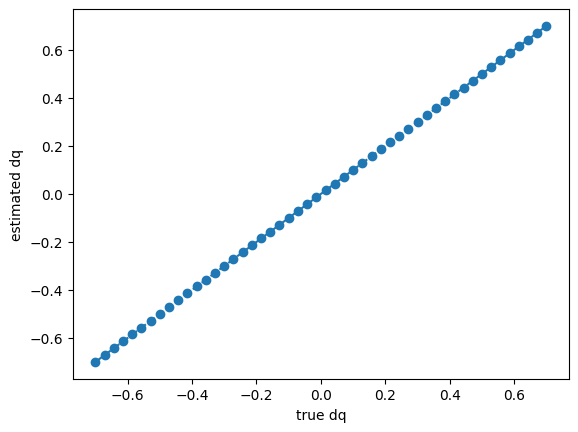

In [7]:
dq_vals = np.linspace(-0.7,0.7,50)

recovered = []

for dq in dq_vals:
    psi = (displace(N, pos_to_alpha(dq))*state).unit()

    s = expect(Sp, psi)

    dq_est = np.angle(s)/(2*sqrt_pi)

    recovered.append(dq_est)

plt.plot(dq_vals, dq_vals, '--')
plt.scatter(dq_vals, recovered)
plt.xlabel("true dq")
plt.ylabel("estimated dq")
plt.show()

Its linear which is goood and hopefully means the conversion of dq to the stabiliser if correct yay


Below does the same correction but with a larger range, and at each lattice site it will now jump to correcting to the next state rather than the origional one once it crosses the descision boundary of $\frac{\sqrt{\pi}}{2}$.

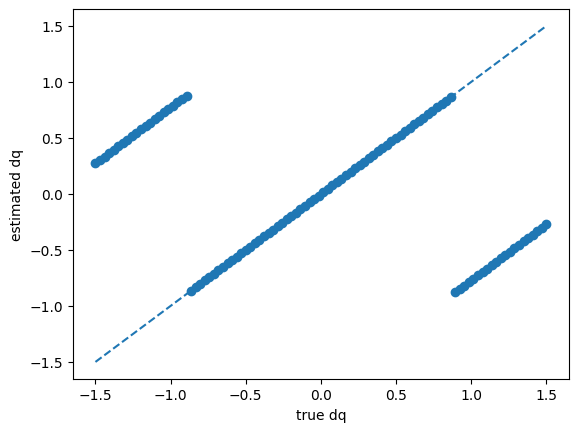

In [8]:
dq_vals = np.linspace(-1.5,1.5,100)

recovered = []

for dq in dq_vals:
    psi = (displace(N, pos_to_alpha(dq))*state).unit()

    s = expect(Sp, psi)

    dq_est = np.angle(s)/(2*sqrt_pi)

    recovered.append(dq_est)

plt.plot(dq_vals, dq_vals, '--')
plt.scatter(dq_vals, recovered)
plt.xlabel("true dq")
plt.ylabel("estimated dq")
plt.show()

Addition of Gaussian Noise

starting with just dq noise

Gaussian noise, with a noise parameter defined above

In [9]:
#noise generation
dq = np.random.normal(0, noise)
#apply noise to a gkp state
psi = (displace(N, pos_to_alpha(dq))*state).unit() #normalise too
#compute expectation value between state and stabiliser
s = expect(Sp, psi)
dq_est = np.angle(s)/(2*sqrt_pi)
#correct - risidual - error yes or no 
correction = -dq_est
residual = dq + correction
print('for random risidual:', residual)

dq = 1.0
psi = (displace(N, pos_to_alpha(dq))*state).unit() #normalise too
#compute expectation value between state and stabiliser
s = expect(Sp, psi)
dq_est = np.angle(s)/(2*sqrt_pi)
#correct - risidual - error yes or no 
correction = -dq_est
residual = dq + correction
print('for a dq that crosses boundary:',residual)

for random risidual: -8.142472703032144e-10
for a dq that crosses boundary: 1.7724538263796519


The random seems to be working, and when i force a large shift it produced a value close to $\sqrt{\pi}$ which is good for a dq of 1.

can apply errors to many qubits now and get a histogram of the gaussian noise

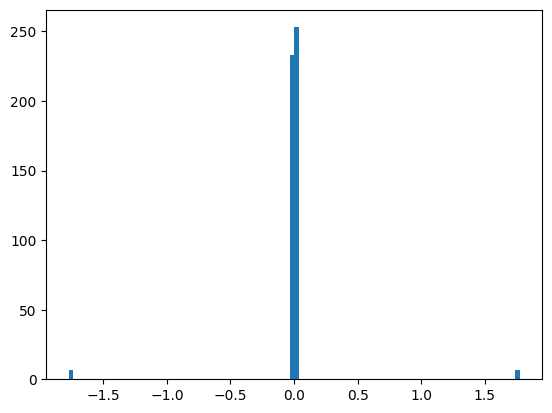

In [10]:
residuals = []

for _ in range(500):
    dq = np.random.normal(0, noise)

    psi = (displace(N, pos_to_alpha(dq))*state).unit()

    s = expect(Sp, psi)
    dq_est = np.angle(s)/(2*sqrt_pi)

    residuals.append(dq - dq_est)

plt.hist(residuals, bins=100)
plt.show()

Here it shows that the states tend to correct to the generated 0 state but can sometimes, with much less likleyhood be corrected to another state if their displacement either side of 0 is high enough. This is much less frequent because the gaussian noise means smaller errors are more poroable.

In [11]:
#unifom dist test it?

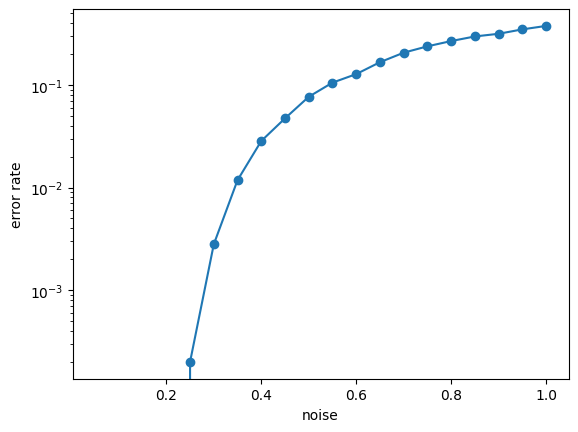

5000


In [12]:
sigma_list = sigma_vals = np.linspace(0.05, 1, 20)
single_error_rates = []

for sigma in sigma_list:
    dq = np.random.normal(0, sigma, n_trials)
    
    # syndrome measurement
    sq = ((dq + sqrt_pi/2) % sqrt_pi) - sqrt_pi/2
    
    # decoder corrects by -sq
    correction = -sq
    residual = dq + correction
    
    # logical error if residual crosses boundary
    k = np.round((residual) / sqrt_pi).astype(int)
    errors = np.mean(k % 2 != 0)
    single_error_rates.append(errors)


plt.semilogy(sigma_list, single_error_rates, marker='o')
plt.xlabel("noise")
plt.ylabel("error rate")
plt.show()

print(n_trials)

In [15]:
def repetition_code(n):
    H = np.zeros((n-1, n), dtype=int)
    for i in range(n-1):
        H[i, i]   = 1
        H[i, i+1] = 1
    return H
d=3
H1 = repetition_code(d)
H2 = repetition_code(d)
H2T = H2.T
r1, n1 = H1.shape
r2, n2 = H2.shape
I2T = np.eye(n2, dtype=int) #identity matrix in the shape of the rows of H1 or H2
I1 = np.eye(r1, dtype=int) #identity matrix in the shape of the columns of H1 or H2

def hypergraphHxHz(H1, H2T, I1, I2T):
    """
    Args:
        H1 (array?): 3 bit code thing
        H2 (_type_): same as above
        I1 (_type_): identity matrix 
        I2T (_type_): identity matrix

    Returns: 
        Hx, Hz for hypergraph codes
    """
    Hxr = np.kron(H1, I2T)
    Hxl= np.kron(I1, H2T)
    Hx = np.hstack([Hxr, Hxl])

    Hzr = np.kron(I2T, H1)
    Hzl = np.kron(H2T, I1)
    Hz = np.hstack([Hzr, Hzl])
    return Hx, Hz

Hx, Hz = hypergraphHxHz(H1, H2T, I1, I2T) #this gives a list of which stabilisers (rows) touch which qubits (columns)
#print(I2T)
print(Hx)
print(Hz)

def get_logical_z(d):
    r = d - 1  # rows of H
    n = d      # cols of H
    n_top = n * n        # = d²
    n_bot = r * r        # = (d-1)²
    n_qubits = n_top + n_bot

    logical = np.zeros(n_qubits, dtype=np.uint8)
    for i in range(n):
        logical[i * n] = 1
    return logical
d=3
logical_z = get_logical_z(d)

[[1 0 0 1 0 0 0 0 0 1 0 0 0]
 [0 1 0 0 1 0 0 0 0 1 1 0 0]
 [0 0 1 0 0 1 0 0 0 0 1 0 0]
 [0 0 0 1 0 0 1 0 0 0 0 1 0]
 [0 0 0 0 1 0 0 1 0 0 0 1 1]
 [0 0 0 0 0 1 0 0 1 0 0 0 1]]
[[1 1 0 0 0 0 0 0 0 1 0 0 0]
 [0 1 1 0 0 0 0 0 0 0 1 0 0]
 [0 0 0 1 1 0 0 0 0 1 0 1 0]
 [0 0 0 0 1 1 0 0 0 0 1 0 1]
 [0 0 0 0 0 0 1 1 0 0 0 1 0]
 [0 0 0 0 0 0 0 1 1 0 0 0 1]]


pymatching small test first

In [16]:
matching = pymatching.Matching.from_check_matrix(Hz)

In [17]:
n_qubits = Hz.shape[1]

e = np.zeros(n_qubits, dtype=np.uint8)
e[0] = 1

syndrome = (Hz @ e) % 2
correction = matching.decode(syndrome)
print(correction)

residual = (e + correction) % 2
print(residual)

logical_fail = (residual @ logical_z) % 2
print(logical_fail)

[1 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 0]
0


test monte calro

In [18]:
print("Hz shape =", Hz.shape)
print("e shape =", e.shape)
print("syndrome shape =", syndrome.shape)
print("matching detectors =", matching.num_detectors)

Hz shape = (6, 13)
e shape = (13,)
syndrome shape = (6,)
matching detectors = 6


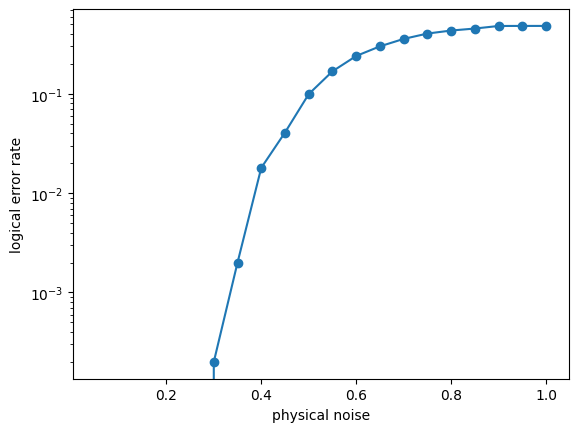

In [19]:
p = 0.05
sigma_vals = np.linspace(0.05, 1, 20)

def surface_gkp_dq(Hz, logical_z, matching, sigma_vals, n_trials):
    logical_rate = []

    for sigma in sigma_vals:
        errors = 0
        physical_errors = 0
        total_qubits = 0

        for _ in range(n_trials):
            e = np.zeros(Hz.shape[1], dtype=np.uint8)
            sq_vals = np.zeros(Hz.shape[1])

            for q in range(Hz.shape[1]):
                dq = np.random.normal(0, sigma)
                sq = ((dq + sqrt_pi/2) % sqrt_pi) - sqrt_pi/2
                sq_vals[q] = sq
                dq_vals[q] = dq
                k = int(np.round((dq - sq)/sqrt_pi))
                e[q] = k % 2

            weights = np.zeros(len(e)) # check this is correct
            
            syndrome = (Hz @ e) % 2
            correction = matching.decode(syndrome, weights=weights)
            residual = (e + correction) % 2

            if (residual @ logical_z) % 2:
                errors += 1

            physical_errors += e.sum()
            total_qubits += len(e)

        logical_rate.append(errors / n_trials)
        #print("physical p =", physical_errors/total_qubits)
    return logical_rate    

logical_rate = surface_gkp_dq(Hz, logical_z, matching, sigma_vals, n_trials)

plt.semilogy(sigma_vals, logical_rate, marker='o') # does yscale log in the plot thats cool
plt.xlabel("physical noise")
plt.ylabel("logical error rate")
plt.show()

The surface code, for noise below 0.45 is correcte better than a normal gkp qubit on its own would. This is just for distance 3, i shall plot them for a few more distances to verify that it follows the intended pattern of correcte better with larger distance below the threshold.

Here it still is onlt for one error. The threshold should be aboyt 50% like a classical threshold

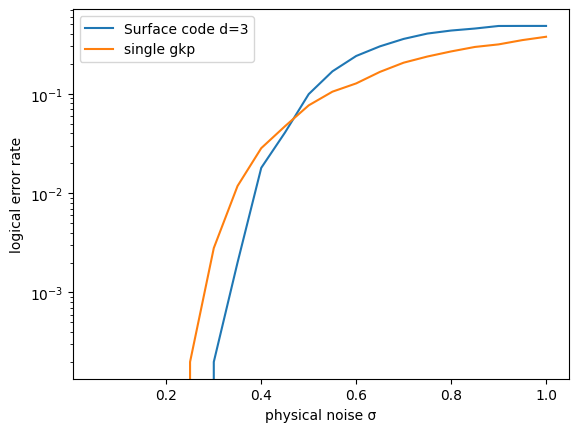

In [20]:
plt.semilogy(sigma_vals, logical_rate, label='Surface code d=3')
plt.semilogy(sigma_list, single_error_rates, label = 'single gkp')
plt.xlabel("physical noise σ")
plt.ylabel("logical error rate")
plt.legend()
plt.show()
plt.show()

Because this just deals with one error type right now the threshold graph should look like a classical one kinda

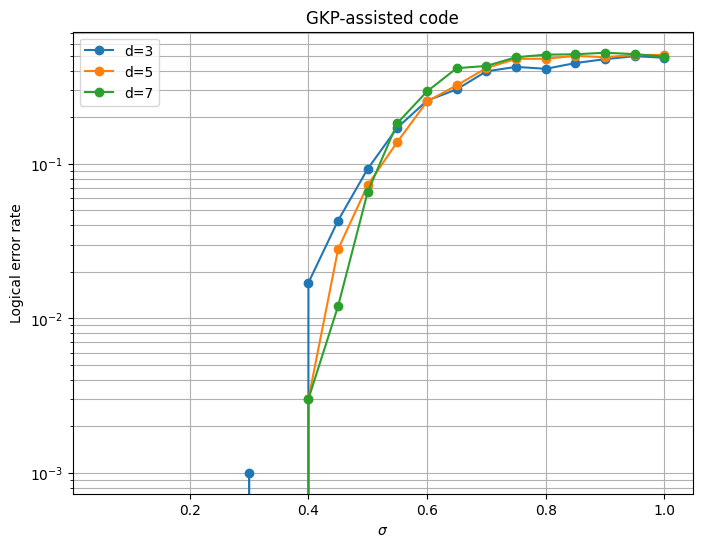

In [21]:
distances = [3, 5, 7]
trials_by_d = {
    3: 1000,
    5: 1000,
    7: 1000,
}

plt.figure(figsize=(8,6))

for d in distances:

    H = repetition_code(d)
    HT = H.T

    r, n = H.shape
    I_n = np.eye(n, dtype=int)
    I_r = np.eye(r, dtype=int)

    _, Hz = hypergraphHxHz(H, HT, I_r, I_n)
    Hz %= 2

    # new matching bc new hz for each distance 
    matching = pymatching.Matching.from_check_matrix(Hz)

    # re construct logical for new distances
    logical_z = logical_z = get_logical_z(d)

    logical_rate = surface_gkp_dq(
        Hz,
        logical_z,
        matching,
        sigma_vals,
        trials_by_d[d]
    )

    plt.semilogy(
        sigma_vals,
        logical_rate,
        marker='o',
        label=f'd={d}'
    )

plt.xlabel(r'$\sigma$')
plt.ylabel('Logical error rate')
plt.title('GKP-assisted code')
plt.grid(True, which='both')
plt.legend()
plt.show()

Need both dp and dq errors so will add dp to the surface code and get a new threshold graph

In [ ]:
def get_logical_x(d):
    r = d - 1  # rows of H
    n = d      # cols of H
    n_top = n * n        # = d2
    n_bot = r * r        # = (d-1)2
    n_qubits = n_top + n_bot

    logical = np.zeros(n_qubits, dtype=np.uint8)
    for i in range(n):
        logical[i] = 1 #changed here
    return logical

In [23]:
d = 3
H = repetition_code(d)
HT = H.T
r, n = H.shape
I_n = np.eye(n, dtype=int)
I_r = np.eye(r, dtype=int)
Hx, Hz = hypergraphHxHz(H, HT, I_r, I_n)
Hx %= 2
Hz %= 2

matching_hz = pymatching.Matching.from_check_matrix(Hz)
matching_hx = pymatching.Matching.from_check_matrix(Hx)

logical_z = get_logical_z(d)
logical_x = get_logical_x(d)

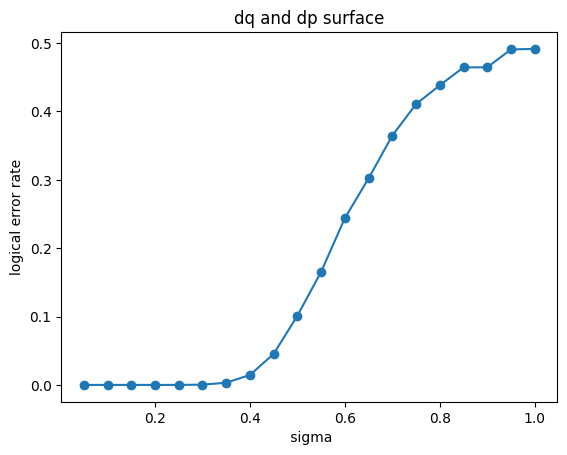

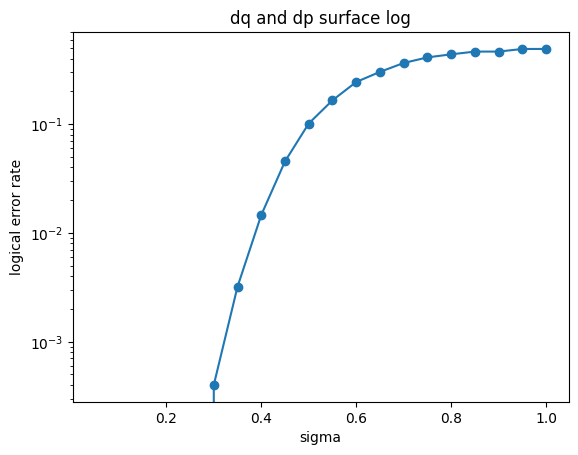

In [25]:
sigma_vals = np.linspace(0.05, 1, 20)

def surface_gkp_dq_dp(Hz, Hx, logical_z, logical_x, matching, sigma_vals, n_trials):
    logical_rate = []

    for sigma in sigma_vals:
        dq_errors = 0
        dp_errors = 0
        #physical_errors = 0
        #total_qubits = 0

        for _ in range(n_trials):
            eq = np.zeros(Hz.shape[1], dtype=np.uint8)
            ep = np.zeros(Hx.shape[1], dtype=np.uint8)
            sq_vals = np.zeros(Hz.shape[1])
            sp_vals = np.zeros(Hx.shape[1])

            for q in range(Hz.shape[1]):
                dq = np.random.normal(0, sigma)
                sq = ((dq + sqrt_pi/2) % sqrt_pi) - sqrt_pi/2
                sq_vals[q] = sq
                kq = int(np.round((dq - sq)/sqrt_pi))
                eq[q] = kq % 2

            for p in range(Hx.shape[1]):
                dp = np.random.normal(0, sigma)
                sp = ((dp + sqrt_pi/2) % sqrt_pi) - sqrt_pi/2
                sp_vals[p] = sp
                kp = int(np.round((dp - sp)/sqrt_pi))
                ep[p] = kp % 2

            #weights_q = np.zeros(len(eq))
            #weights_p = np.zeros(len(ep))

            weights_q = (sq_vals ** 2) / (2 * sigma**2)  # log-likelihood ratio
            weights_p = (sp_vals ** 2) / (2 * sigma**2)
            
            syndrome_q = (Hz @ eq) % 2
            correction_q = matching_hz.decode(syndrome_q, weights=weights_q)
            residual_q = (eq + correction_q) % 2

            syndrome_p = (Hx @ ep) % 2
            correction_p = matching_hx.decode(syndrome_p, weights=weights_p)
            residual_p = (ep + correction_p) % 2

            if (residual_q @ logical_z) % 2:
                dq_errors += 1

            if (residual_p @ logical_x) % 2:
                dp_errors += 1

        errors = dq_errors + dp_errors
            #physical_errors += e.sum()
            #total_qubits += len(e)

        logical_rate.append(errors / (2 * n_trials))
        #print("physical p =", physical_errors/total_qubits)
    return logical_rate    

logical_rate1 = surface_gkp_dq_dp(Hz, Hx, logical_z, logical_x, matching, sigma_vals, n_trials)

plt.plot(sigma_vals, logical_rate1, marker='o')
plt.xlabel(" sigma")
plt.ylabel("logical error rate")
plt.title('dq and dp surface')
plt.show()

plt.semilogy(sigma_vals, logical_rate1, marker='o')
plt.xlabel("sigma")
plt.ylabel("logical error rate")
plt.title('dq and dp surface log')
plt.show()

I think bc this is logiacl vs sigma, the spread of the gaussian nosie, its a good graph.

In [ ]:
distances = [3, 5, 7]
trials_by_d = {
    3: 10000,
    5: 10000,
    7: 10000,
}

plt.figure(figsize=(8,6))

for d in distances:

    H = repetition_code(d)
    HT = H.T

    r, n = H.shape
    I_n = np.eye(n, dtype=int)
    I_r = np.eye(r, dtype=int)

    Hx, Hz = hypergraphHxHz(H, HT, I_r, I_n)
    Hx %= 2
    Hz %= 2
    
    matching_hz = pymatching.Matching.from_check_matrix(Hz)
    matching_hx = pymatching.Matching.from_check_matrix(Hx)

    logical_z = get_logical_z(d)
    logical_x = get_logical_x(d)


    logical_rate1 = surface_gkp_dq_dp(Hz, Hx, logical_z, logical_x, matching, sigma_vals, n_trials)

    plt.semilogy(
        sigma_vals,
        logical_rate1,
        marker='o',
        label=f'd={d}'
    )

plt.xlabel(r'$\sigma$')
plt.ylabel('Logical error rate')
plt.title('GKP-assisted code')
plt.grid(True, which='both')
plt.legend()
plt.show()

https://journals.aps.org/pra/pdf/10.1103/PhysRevA.99.032344

I think it looks like one of thse

The Toric code is the 2D surface code

In [ ]:
from scipy.sparse import hstack, kron, eye, csc_matrix, block_diag

In [ ]:
#def toric_x_stab(d): #i think d is my L they use in the tutorial
# i think this just makes Hz and Hx which i already have
# and i also have the logicals 
# might be worth switching to the other style
#they vectorise it can i do that